<table style="width:100%; float:center; background-color:#FFFFFF" align="left">
<tr>
<td style="text-align:left; background-color:#FFFFFF"></td>
<td style="text-align:right; background-color:#FFFFFF"><div>
<image src="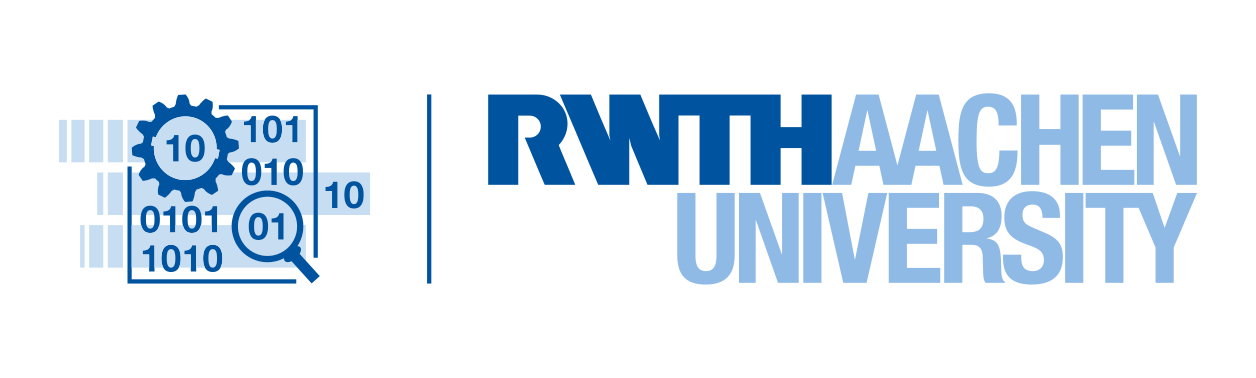" width="500">
    
</div>
</td></tr>
</table>

Prof. Dr. Sandra Geisler <br>
Anastasiia Belova, Soo-Yon Kim

April 28, 2025

<center>

<h1> Data Stream Management and Analysis <br />(Summer Term 2025)</h1>
    
<h1> Exercise 1</h1>
    
</center>

---
**Due until Monday, May 12 at 8:00 am.
Please submit your solutions as a Jupyter notebook to Moodle.
Please do _not_ submit handwritten solutions! Your solutions should be submitted in groups of 4 students.**
Solutions to this exercise will be presented on Friday, May 16.

---

### Group members: [Luyang Huang, 466716], [Feiyu Wang, 460101], [Yansong Liu, 453322], [Xingjian Tian, 436949] 
#### Insert all group members by double-clicking on this cell.

---

## How to fill in the assignment

For coding tasks, you will find code cells marked with: `#YOUR CODE HERE`  
Please insert your code into that cell.

For written tasks, you will find Markdown cells marked with: `Please replace this text with your answer.`  
Here, you can double-click to edit the cell and use [Markdown](https://markdown.de/) to format the answer.

## Task 1 (ksql Queries) (8 pts)

Assume you are given two different streams `bitcoin_kraken_stream` and `bitcoin_binance_stream` which contain trading data for bitcoin from the currency markets **kraken** and **binance**.

Consider the following schema definitions:  


```json
{
 "schema_definitions" : [
  {
   "type": "record",
   "name": "binance",
   "fields": [
       {"name": "datetime", "type": "string"},
       {"name": "ask", "type": "double"},
       {"name": "bid", "type": "double"},
       {"name": "last_trade", "type": "double"},
       {"name": "dummy", "type": "int"},
   ]
  },
  {
   "type": "record",
   "name": "kraken",
   "fields": [
       {"name": "datetime", "type": "string"},
       {"name": "ask", "type": "double"},
       {"name": "bid", "type": "double"},
       {"name": "last_trade", "type": "double"},
       {"name": "volume_day_last24h", "type": "double"},
       {"name": "volume_weighted_average_price_array_last24h", "type": "double"},
       {"name": "dummy", "type": "int"},
   ]
  }
 ]
}
```

Assume that `bitcoin_kraken_stream` and `bitcoin_binance_stream` both have their timestamps set to the explicit timestamp column `datetime` over their implicit timestamp pseudo column `ROWTIME`.

A detailed description of the dataset can be found in moodle in the file 'dataset_description.pdf'.

Formulate the following queries as expressions in ksql:

1. Create a stream `btceur_kraken_stream` containing all tuples of the `bitcoin_kraken_stream`, for which the `ask` and `bid` prices are less than 20 cents apart.
2. Calculate and emit the average price of bitcoin in 60 second intervals, which advance every 15 seconds, of the `bitcoin_kraken_stream`, based on the prices bitcoin was traded for ("last_trade").
3. Determine the average buying price of bitcoin from `bitcoin_kraken_stream` in 30 second intervals. Store the results in a table `avg_btc_price_kraken_30_s`.
4. Join the streams `bitcoin_kraken_stream` and `bitcoin_binance_stream` on the `ROWTIME` pseudo column within a window of 30 seconds. Calculate and emit the price differences at the corresponding points. 

*Hints: 1. You may use 'dummy' columns from both datasets as an input for GROUP BY. 2. The way the schema is given, type casting is not required for the solution. However, to successfully run the query using Kafka and the provided dataset, it is.* </br>

### Solution

#### Query 1

```sql
CREATE STREAM btceur_kraken_stream AS
SELECT *
FROM bitcoin_kraken_stream
WHERE (CAST(ask AS double) - CAST(bid AS double)) < 0.2
EMIT CHANGES;
```

#### Query 2

```sql
SELECT dummy, AVG(CAST(last_trade as double)) AS avg_price_60s
FROM bitcoin_kraken_stream
WINDOW HOPPING (SIZE 60 SECONDS, ADVANCE BY 15 SECONDS)
GROUP BY dummy
EMIT CHANGES;
```

#### Query 3

```sql
CREATE TABLE avg_btc_price_kraken_30_s AS
SELECT dummy, AVG(CAST(last_trade AS double)) AS avg_buy_price
FROM bitcoin_kraken_stream
WINDOW TUMBLING (SIZE 30 SECONDS)
GROUP BY dummy
EMIT CHANGES;
```

#### Query 4

```sql
SELECT 
    k.datetime AS timestamp,
    k.last_trade,
    b.last_trade,
    (CAST(k.last_trade AS double) - CAST(b.last_trade AS double)) AS price_difference
FROM bitcoin_kraken_stream k
INNER JOIN bitcoin_binance_stream b 
WITHIN 30 SECONDS
ON k.ROWTIME = b.ROWTIME
EMIT CHANGES;
```

<div class = "alert alert-success">

Query 4

- Absolute function for price difference is missing -0.5pt

__7.5/8__
</div>

## Task 2 (Lambda Queries) (4 pts)


Assume the following stream is given in ksqlDB, where the name of a bitcoin market is mapped to an array of bids over an interval:
```sql
CREATE STREAM bitcoin (
  interval INT,
  lambda_map MAP<STRING, ARRAY<INTEGER>>
)
```

For example, the stream could contain the following element:
```
  1, MAP('kraken':= ARRAY[26911, 26912, 26921], 'binance':= ARRAY[26999,26982])
```

Query the bitcoin stream in ksql, using only (potentially nested) lambda and scalar functions of the following form:
```sql
SELECT interval, 
LAMBDA EXPRESSION
FROM bitcoin
EMIT CHANGES;
```

1. For each interval, return the maximum bid reported by each market. 

```
TRANSFORM(lambda_map, (market, bids) => ARRAY_MAX(bids)) AS max_bid_per_market
```

2. For each interval, return the highest bid across all markets.

```
ARRAY_MAX ( MAP_VALUES ( TRANSFORM ( lambda_map, (market, bids) => market, (market, bids) => ARRAY_MAX(bids) )))
EMIT CHANGES;
```

Please note that solutions without well-defined syntax (e.g., with syntax invented by generative AI, that does not exist in ksqlDB) will be considered incorrect. You can consult the following links for researching ksqlDB syntax.

https://docs.confluent.io/platform/current/ksqldb/developer-guide/ksqldb-reference/scalar-functions.html  
https://docs.confluent.io/platform/current/ksqldb/how-to-guides/use-lambda-functions.html

<div class ="alert alert-success">

__4/4__

</div>

## Task 3 (Timestamps) (2 pts)

Assume that you want to join two streams containing accurately timestamped trading data from two high-frequency trading markets (similar to Task 1.4). The latency and jitter on the data path between the markets and the data stream processor varies between both markets.
Would you choose implicit or explicit timestamps? Give reasons for your solution.

#### Explicit timestamps
Using explicit timestamps avoids problem caused by latency and jitter. On the contrary, implicit timestamps are easily affected by latency and jitter, which might cause problem that two transactions finished at different time are joined or two transactions finished at the same time are not joined.

<div class = "alert alert-success">

__2/2__
</div>

## Task 4 (Window Semantics) (6 pts)

Given is the following snapshot of a stream S, with timestamps in seconds. Assume that the earliest timestamp is 1:


| timestamp | temperature | component |
| --- | --- | --- |
|1|21.2|env1|
|2|21.1|env1|
|2|21.6|env2|
|3|20.1|env2|
|3|20.3|env1|
|4|21.1|env2|
|4|21.7|env1|
|5|21.3|env2|
|5|20.2|env1|
|6|21.5|env2|

1\. What is the content of the stream at time $\tau_4$, i.e., $S(\tau_4)$? You can leave out the multiplicities.




$ S(\tau_{4}) $ = {(1,21.2,env1), (2,21.1,env1), (2,21.6,env2), (3,20.1,env2), (3,20.3,env1), (4,21.1,env2), (4,21.7,env1)}


2\. Give all output stream elements of the following query Q up to time $\tau_6$ ($\tau_6$ included). Explain your result.
``` sql
SELECT component, AVG(temperature) AS avgTemp FROM S
WINDOW TUMBLING (3 SECONDS)
GROUP BY component;
```

| timestamp | temperature | component |
| --- | --- | --- |
|3|env1|20.87|
|3|env2|20.85|
|6|env1|20.95|
|6|env2|21.3|

# Explanation
Because there is no overlapping in tumbling window and timestamp starts at 1, there are 2 time intervals here, separately [1,4) and [4,6). Then we compute average temperature of each component in each time interval. As the result, 4 tuples are shown. 

3\. Instead of the tumbling window in part 2, the average should be computed over 4 tuples. Each tuple should be considered for two consecutive averaging operations. 
State the window you are using and how it is parameterized. Refer to the concepts of the lecture. Your window definition does not need to be valid in ksqlDB.
Give all output stream elements of the following query Q up to time $\tau_6$ ($\tau_6$ included).


WINDOW HOPPING (SIZE 4 TUPLES, ADVANCE BY 2 TUPLES)<br>

| timestamp | component | avgTemp |
| --- | --- | --- |
|3|env1|21.15|
|3|env2|20.85|
|4|env1|20.3|
|4|env2|20.93|
|5|env1|21|
|5|env2|21.2|
|6|env1|20.95|
|6|env2|21.4|

<div class ="alert alert-success">


__6/6__

</div>